In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn import preprocessing
from dgl.data import DGLDataset
import dgl
import time
import networkx as nx
import category_encoders as ce
import torch.nn as nn
import torch.nn.functional as F
import dgl.function as fn
import torch
import tqdm
import math

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score

from typing import *
from sklearn.preprocessing import StandardScaler, Normalizer
import socket
import struct
import random
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

In [2]:
df_train = pd.read_csv("train_embedded.csv")
df_test = pd.read_csv("test_embedded.csv")

train_labels = df_train["Label"]
test_labels = df_test["Label"]

train_samples  = df_train.drop(columns=["Label", "Attack"])
test_samples = df_test.drop(columns=["Label", "Attack"])

In [3]:
corr_labels = train_samples.corrwith(train_labels)
desc_list_corr = (corr_labels).argsort().values

col_keep_ratio = 100
cols_to_keep = desc_list_corr[:len(desc_list_corr)*col_keep_ratio//100 ]
cols_to_keep = [str(i) for i in cols_to_keep]
train_samples = train_samples[cols_to_keep]
test_samples = test_samples[cols_to_keep]

In [4]:
df_train_xai = pd.read_parquet("graph_explainers_df.parquet")

In [5]:
def train_and_test(explainer_name, ratio_perc_to_keep, train_samples, train_labels, test_samples, test_labels, sorted_list):
    selected_samples = sorted_list[:len(sorted_list)*ratio_perc_to_keep//100]
    X_train = train_samples.loc[selected_samples]
    Y_train = train_labels.loc[selected_samples]
    X_test = test_samples
    Y_test = test_labels
    X_scaler = StandardScaler()
    X_train = X_scaler.fit_transform(X_train)
    X_test = X_scaler.transform(X_test)
    model = CatBoostClassifier(iterations=250,
                            learning_rate=0.1,
                            depth=3,
                            verbose=0)
    try:
        model.fit(X_train, Y_train)
    except Exception as e:
        print(f"Error on {explainer_name} {ratio_perc_to_keep} : {e} ")
        return {
        'dataset': ratio_perc_to_keep,
        'model': explainer_name,
        'acc': None,
        'f1_macro': None,
        'precision': None,
        'recall': None
    }
    Y_predicted = model.predict(X_test)
    return {
        'dataset': ratio_perc_to_keep,
        'model': explainer_name,
        'acc': accuracy_score(Y_test,Y_predicted),
        'f1_macro': f1_score(Y_test, Y_predicted, average='macro'),
        'precision': precision_score(Y_test,Y_predicted),
        'recall': recall_score(Y_test,Y_predicted)
    }

In [6]:
df_results = []
sorted_list = df_train_xai.sort_values(by=['GNNExplainer']).index
for i in tqdm.tqdm(range(10,96,5)):
    print("Running", i)
    df_results.append(train_and_test("GNNExplainer", i , train_samples, train_labels, test_samples, test_labels, sorted_list))

  0%|                                               | 0/18 [00:00<?, ?it/s]

Running 10


  6%|██▏                                    | 1/18 [00:15<04:19, 15.29s/it]

Running 15


 11%|████▎                                  | 2/18 [00:32<04:23, 16.44s/it]

...

 89%|█████████████████████████████████▊    | 16/18 [07:58<01:03, 31.89s/it]

Running 90


 94%|███████████████████████████████████▉  | 17/18 [08:27<00:31, 31.28s/it]

Running 95


100%|██████████████████████████████████████| 18/18 [08:59<00:00, 29.95s/it]


In [7]:
pd.DataFrame(df_results)

,dataset,model,acc,f1_macro,precision,recall
0,10,GNNExplainer,0.993007,0.983082,0.997302,0.944386
1,15,GNNExplainer,0.993234,0.983632,0.998183,0.945441
2,20,GNNExplainer,0.991094,0.978287,0.997969,0.927810
3,25,GNNExplainer,0.993024,0.983121,0.997449,0.944386
4,30,GNNExplainer,0.993584,0.984501,0.998101,0.948440
5,35,GNNExplainer,0.993200,0.983547,0.998387,0.944969
6,40,GNNExplainer,0.993194,0.983532,0.998270,0.945024
7,45,GNNExplainer,0.993027,0.983115,0.998472,0.943442
8,50,GNNExplainer,0.993414,0.984077,0.998331,0.946801
9,55,GNNExplainer,0.991071,0.978224,0.998207,0.927393


In [8]:
sorted_list = df_train_xai.sort_values(by=['PGExplainer']).index
for i in tqdm.tqdm(range(10,96,5)):
    print("Running", i)
    df_results.append(train_and_test("PGExplainer", i , train_samples, train_labels, test_samples, test_labels, sorted_list))

  0%|                                               | 0/18 [00:00<?, ?it/s]

Running 10


  6%|██▏                                    | 1/18 [00:07<02:00,  7.06s/it]

Running 15


 11%|████▎                                  | 2/18 [00:15<02:05,  7.86s/it]

...

 89%|█████████████████████████████████▊    | 16/18 [04:52<00:51, 25.92s/it]

Running 90


 94%|███████████████████████████████████▉  | 17/18 [05:22<00:27, 27.23s/it]

Running 95


100%|██████████████████████████████████████| 18/18 [05:43<00:00, 19.09s/it]


In [9]:
pd.DataFrame(df_results)

,dataset,model,acc,f1_macro,precision,recall
0,10,GNNExplainer,0.993007,0.983082,0.997302,0.944386
1,15,GNNExplainer,0.993234,0.983632,0.998183,0.945441
2,20,GNNExplainer,0.991094,0.978287,0.997969,0.927810
3,25,GNNExplainer,0.993024,0.983121,0.997449,0.944386
4,30,GNNExplainer,0.993584,0.984501,0.998101,0.948440
5,35,GNNExplainer,0.993200,0.983547,0.998387,0.944969
6,40,GNNExplainer,0.993194,0.983532,0.998270,0.945024
7,45,GNNExplainer,0.993027,0.983115,0.998472,0.943442
8,50,GNNExplainer,0.993414,0.984077,0.998331,0.946801
9,55,GNNExplainer,0.991071,0.978224,0.998207,0.927393


In [11]:
#sorted_list = df_train_xai.sort_values(by=['SHAP']).index
#for i in tqdm.tqdm(range(35,96,5)):
#    print("Running", i)
#    df_results.append(train_and_test("SHAP", i , train_samples, train_labels, test_samples, test_labels, sorted_list))

In [10]:
#last
acc_ref=0.994784
f1_macro_ref=0.987396
precision_ref=0.998953
recall_ref=0.957421

In [76]:
#old
#acc_ref=0.993922
#f1_macro_ref=0.985285
#precision_ref=0.997386
#recall_ref=0.951708

In [77]:
#pd.set_option("display.precision", 5)

In [12]:
pdf_results = pd.DataFrame(df_results)
pdf_results["acc_drop"] = (acc_ref - pdf_results["acc"]) / acc_ref
pdf_results["f1_macro_drop"] = (f1_macro_ref - pdf_results["f1_macro"]) / f1_macro_ref
pdf_results["precision_drop"] = (precision_ref - pdf_results["precision"]) / precision_ref
pdf_results["recall_drop"] = (recall_ref - pdf_results["recall"]) / recall_ref

pdf_results

,dataset,model,acc,f1_macro,precision,recall,acc_drop,f1_macro_drop,precision_drop,recall_drop
0,10,GNNExplainer,0.993007,0.983082,0.997302,0.944386,0.001786,0.004370,0.001652,0.013615
1,15,GNNExplainer,0.993234,0.983632,0.998183,0.945441,0.001558,0.003812,0.000771,0.012513
2,20,GNNExplainer,0.991094,0.978287,0.997969,0.927810,0.003709,0.009225,0.000985,0.030928
3,25,GNNExplainer,0.993024,0.983121,0.997449,0.944386,0.001770,0.004330,0.001506,0.013615
4,30,GNNExplainer,0.993584,0.984501,0.998101,0.948440,0.001206,0.002932,0.000853,0.009381
5,35,GNNExplainer,0.993200,0.983547,0.998387,0.944969,0.001592,0.003898,0.000567,0.013006
6,40,GNNExplainer,0.993194,0.983532,0.998270,0.945024,0.001599,0.003914,0.000684,0.012948
7,45,GNNExplainer,0.993027,0.983115,0.998472,0.943442,0.001766,0.004336,0.000482,0.014601
8,50,GNNExplainer,0.993414,0.984077,0.998331,0.946801,0.001377,0.003361,0.000622,0.011092
9,55,GNNExplainer,0.991071,0.978224,0.998207,0.927393,0.003733,0.009289,0.000747,0.031363


In [13]:
#pdf_results= pd.read_csv("pdf_results-Copy1.csv")

#pdf_results["acc_drop"]  = pdf_results["acc_drop"].abs()
#pdf_results["f1_macro_drop"]  = pdf_results["f1_macro_drop"].abs()
#pdf_results["precision_drop"]  = pdf_results["precision_drop"].abs()
#pdf_results["recall_drop"]  = pdf_results["recall_drop"].abs()


In [14]:
pdf_results.to_csv('pdf_results_22102218.csv')

In [15]:
pdf_results=pdf_results[(pdf_results.model=="GNNExplainer") | (pdf_results.model=="PGExplainer")]
#pdf_results=pdf_results[(pdf_results.dataset==25) | (pdf_results.dataset==50) | (pdf_results.dataset==75) | (pdf_results.dataset==95)]

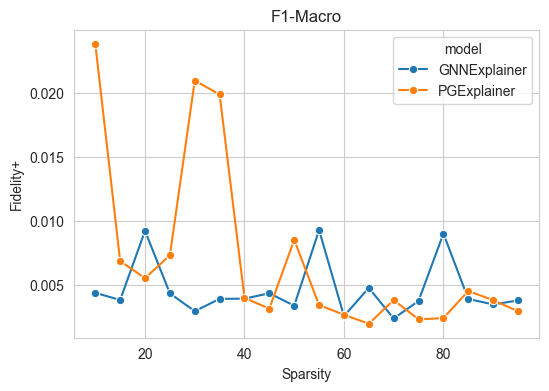

In [16]:
plt.figure(figsize=(6,4))
sns.set_style(style='whitegrid') 
ax = sns.lineplot(
    data=pdf_results[(pdf_results.model=="GNNExplainer") | (pdf_results.model=="PGExplainer")],
    x='dataset', 
    y='f1_macro_drop', 
    marker="o",
    hue="model"

)
#plt.ylim((-0.11),1.25)
ax.set(xlabel ="Sparsity", ylabel = "Fidelity+", title = "F1-Macro")
plt.show()
fig = ax.get_figure()
fig.savefig("f1_drop.png")

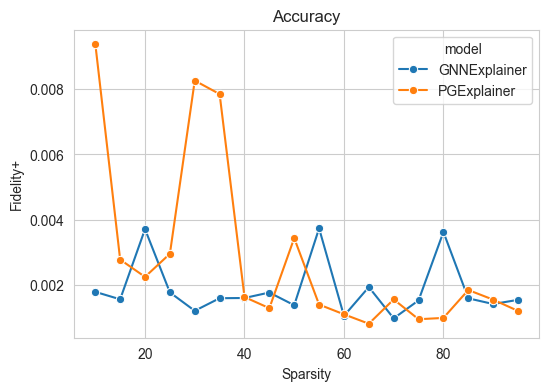

In [17]:
plt.figure(figsize=(6,4))
sns.set_style(style='whitegrid') 
ax = sns.lineplot(
    data=pdf_results[(pdf_results.model=="GNNExplainer") | (pdf_results.model=="PGExplainer")], 
    x='dataset', 
    y='acc_drop', 
    marker="o",
    hue="model"
)

#plt.ylim((-0.1),0.6)
ax.set(xlabel ="Sparsity", ylabel = "Fidelity+", title = "Accuracy")
plt.show()
fig = ax.get_figure()
fig.savefig("acc_drop.png")


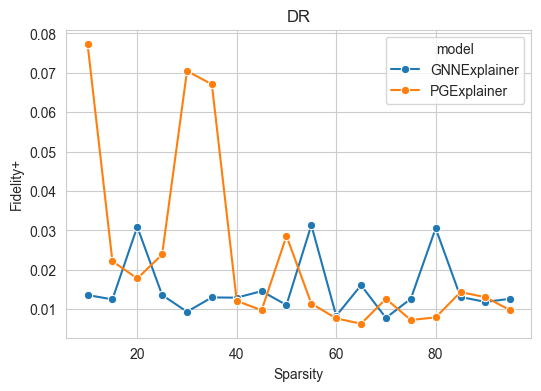

In [18]:
plt.figure(figsize=(6,4))
sns.set_style(style='whitegrid') 
ax = sns.lineplot(
    data=pdf_results[(pdf_results.model=="GNNExplainer") | (pdf_results.model=="PGExplainer")], 
    x='dataset', 
    y='recall_drop', 
    marker="o",
    hue="model",
)

#plt.ylim((-0.5),1.25)
ax.set(xlabel ="Sparsity", ylabel = "Fidelity+", title = "DR")
plt.show()
fig = ax.get_figure()
fig.savefig("recall_drop.png")
